# SPT3G D1

In [3]:
import MCtools
from getdist import plots, MCSamples
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline
DBdir = "/sps/planck/Users/tristram/Soft/Hillik/SPT3G_D1/chains"
clth = hp.read_cl( "/sps/planck/Users/tristram/Models/planck_base_planck_2018_TTTEEElowllowE.fits")
lth = np.arange(len(clth[0]))
freqs = ['90','150','220']

In [2]:
runnames = ['candl_spt3g','hillik_spt3g','hillik_spt3g_nobeta','hillik_spt3g_alphacib','hillik_spt3g_fitxi']
chains = [MCtools.mergeMC( "%s/%s/mcmc" % (DBdir,run), burnin=0.6, weights=True) for run in runnames]

candl_spt3g: 241477  240731  242520  243504 
hillik_spt3g: 197649  196801  203153  197624 
hillik_spt3g_nobeta: 98930  90893  90881  91573 
hillik_spt3g_alphacib: 181155  172591  177121  177181 
hillik_spt3g_fitxi: 41807  41257  42137  41643 


Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


<Figure size 1000x1000 with 0 Axes>

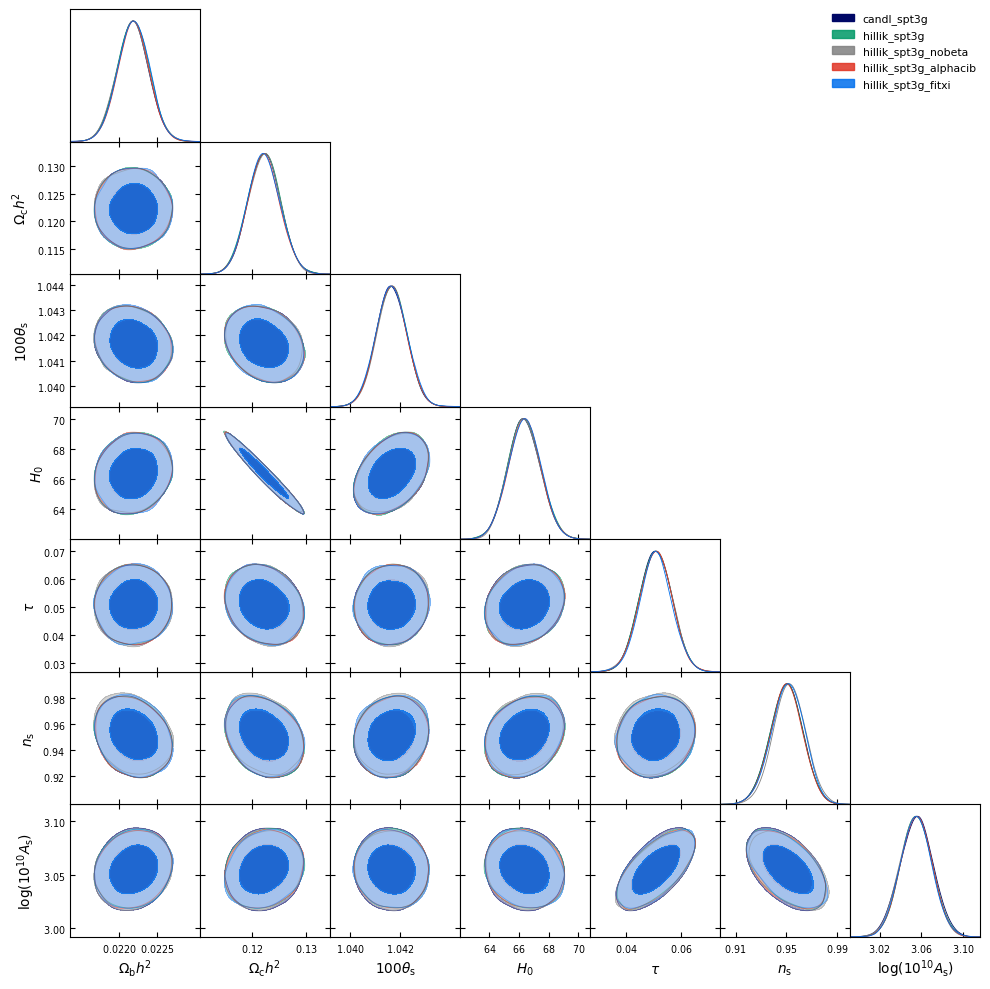

In [3]:
listpar = ['omegabh2','omegach2','theta_s_100','H0','tau','ns','logA']
labels = [MCtools.parname.get(p,p).replace('$','') for p in listpar]
samples = [MCSamples( samples=[chain[p] for p in listpar], names=listpar, labels=labels, weights=chain['weight'], 
                     ranges={'tau':(0.01,0.15)}) for chain in chains]
g = plots.getSinglePlotter(width_inch=10, ratio=1)
g.triangle_plot(samples, listpar, filled=True, legend_labels=runnames, legend_loc='upper right')

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


<Figure size 1000x1000 with 0 Axes>

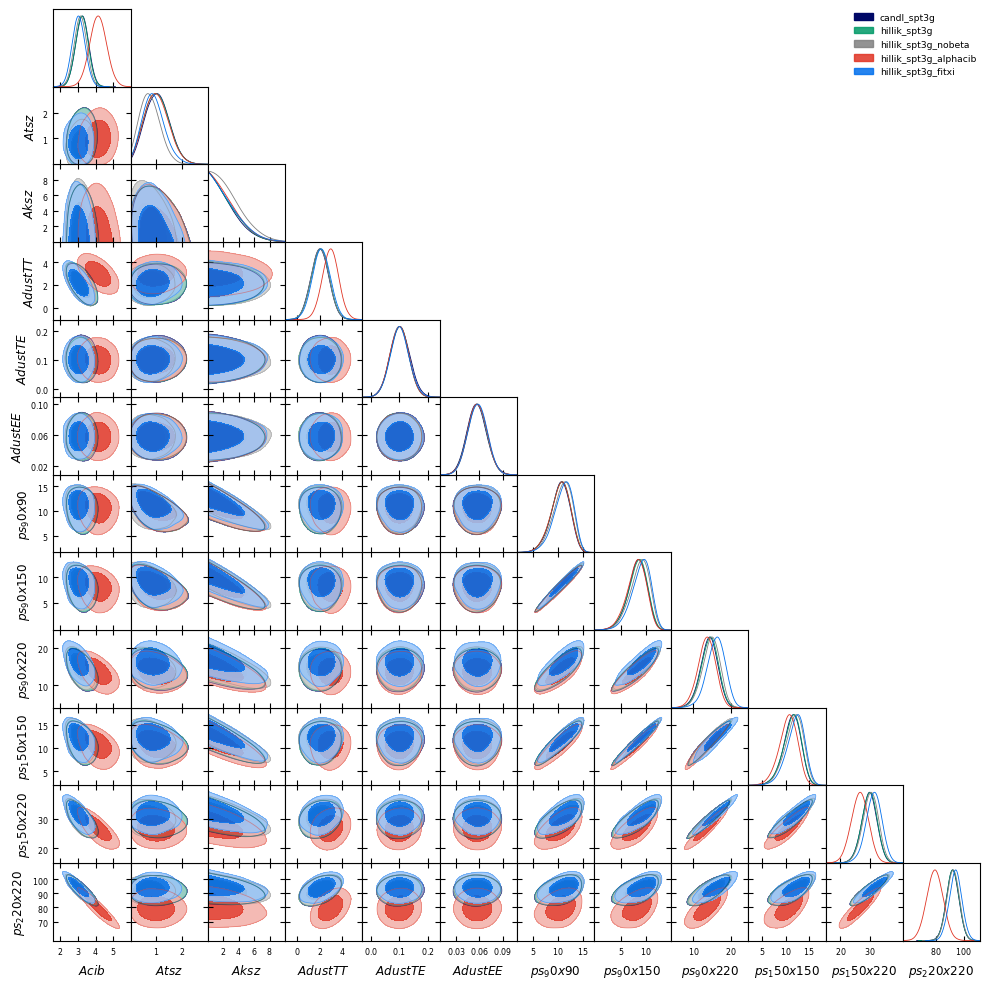

In [4]:
for k,v in {'Atsz':'TT_tSZ_Amp','Aksz':'TT_kSZ_Amp','Acib':'TT_CIBClustering_Amp'}.items(): chains[0][k] = chains[0][v]
for k,v in {'SPT3G_AdustTT':'TT_GalCirrus_Amp','SPT3G_AdustTE':'TE_PolGalDust_Amp','SPT3G_AdustEE':'EE_PolGalDust_Amp'}.items(): chains[0][k] = chains[0][v]
for par in [p for p in chains[0].keys() if 'Poisson' in p]: chains[0][par.replace('TT_Poisson','SPT3G_ps')] = chains[0][par]
listpar = ['Acib','Atsz','Aksz','SPT3G_AdustTT','SPT3G_AdustTE','SPT3G_AdustEE',
           'SPT3G_ps_90x90','SPT3G_ps_90x150','SPT3G_ps_90x220','SPT3G_ps_150x150','SPT3G_ps_150x220','SPT3G_ps_220x220']
labels = [p.replace('SPT3G_','') for p in listpar]
samples = [MCSamples(samples=[chain[p] for p in listpar], names=listpar, labels=labels, weights=chain['weight'], 
                     ranges={'Atsz':(0,10),'Aksz':(0,10),'Acib':(0,10)}) for chain in chains]
g = plots.getSinglePlotter(width_inch=10, ratio=1)
g.triangle_plot(samples, listpar, filled=True, legend_labels=runnames, legend_loc='upper right')

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


<Figure size 1000x1000 with 0 Axes>

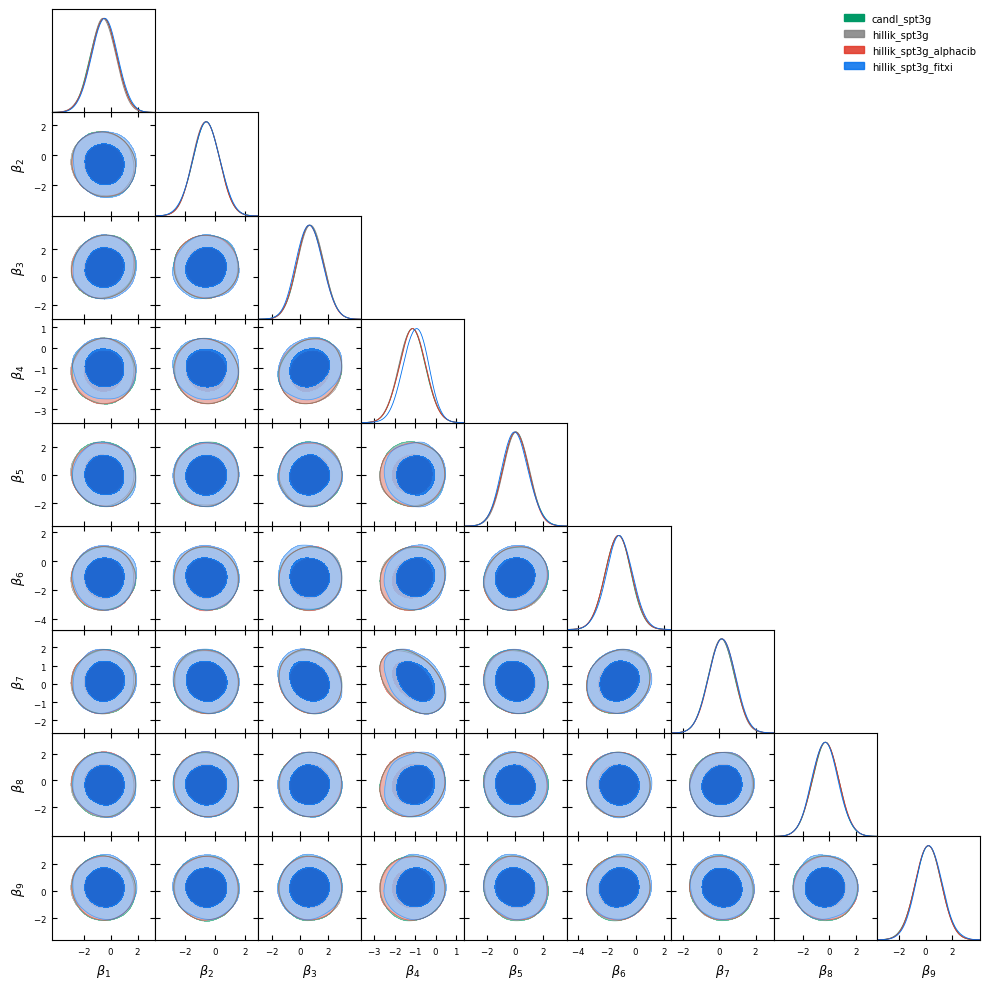

In [5]:
subchains = [('SPT3G_beta_1' in chain) or ('beta_1' in chain) for chain in chains]
listpar = [f'beta_{i}' for i in range(1,10)]
for par in listpar: 
    for chain in np.array(chains)[subchains][1:]: chain[par] = chain['SPT3G_'+par]
labels = [p.replace('beta','\\beta') for p in listpar]
samples = [MCSamples( samples=[chain[p] for p in listpar], names=listpar, labels=labels, weights=chain['weight'], ranges={}) for chain in np.array(chains)[subchains]]
g = plots.getSinglePlotter(width_inch=10, ratio=1)
g.triangle_plot(samples, listpar, filled=True, legend_labels=np.array(runnames)[subchains],legend_loc = 'upper right')

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


<Figure size 1000x1000 with 0 Axes>

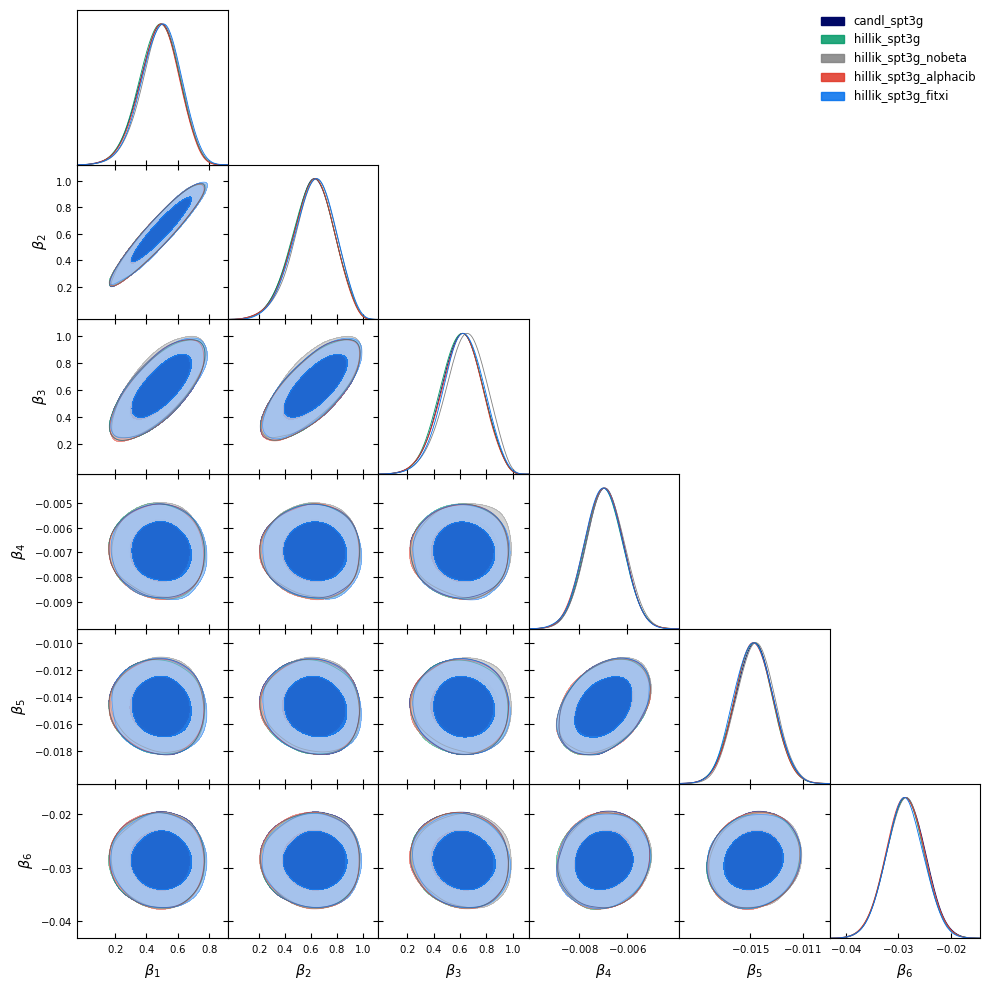

In [6]:
listpar = [f'beta_pol_{fq}' for fq in freqs]+[f'T2P2_{fq}' for fq in freqs]
for par in listpar: 
    for chain in chains[1:]: chain[par] = chain['SPT3G_'+par]
samples = [MCSamples( samples=[chain[p] for p in listpar], names=listpar, labels=labels, weights=chain['weight'], ranges={}) for chain in chains]
g = plots.getSinglePlotter(width_inch=10, ratio=1)
g.triangle_plot(samples, listpar, filled=True, legend_labels=runnames, legend_loc='upper right')

### Point sources

In [6]:
runnames = ['hillik_spt3g_nopsprior','hillik_spt3g_ps','hillik_spt3g_pspriors','hillik_spt3g_2cibbeta']
chains = [MCtools.mergeMC( "%s/%s/mcmc" % (DBdir,run), burnin=0.8, weights=True) for run in runnames]

hillik_spt3g_nopsprior: 210409  205850  212894  201241 
hillik_spt3g_ps: 224060  221935  215841  224976 
hillik_spt3g_pspriors: 132659  133973  132935  134161 
hillik_spt3g_2cibbeta: 173673  174081  159751  173247 


Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


<Figure size 1000x1000 with 0 Axes>

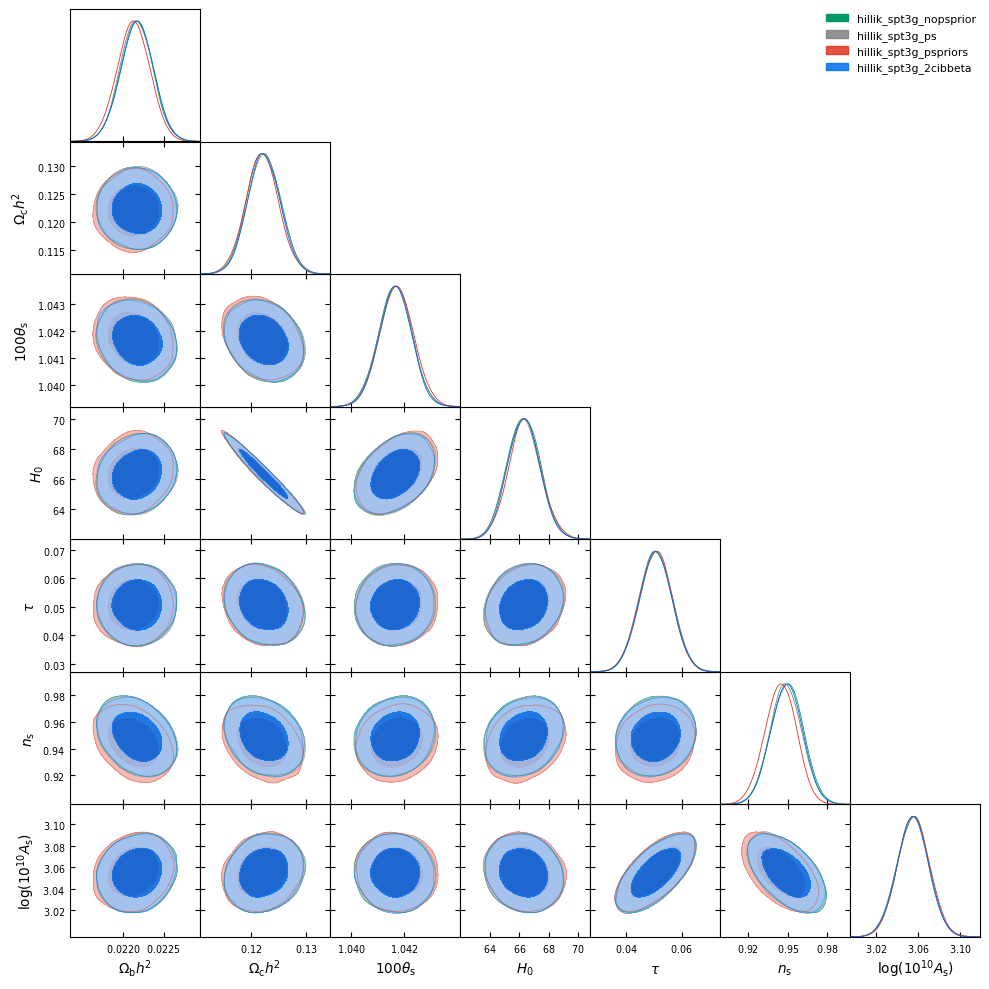

In [7]:
listpar = ['omegabh2','omegach2','theta_s_100','H0','tau','ns','logA']
labels = [MCtools.parname.get(p,p).replace('$','') for p in listpar]
samples = [MCSamples( samples=[chain[p] for p in listpar], names=listpar, labels=labels, weights=chain['weight'],
                     ranges={'tau':(0.01,0.15)}) for chain in chains]
g = plots.getSinglePlotter(width_inch=10, ratio=1)
g.triangle_plot(samples, listpar, filled = True, legend_labels = runnames,legend_loc = 'upper right')

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


<Figure size 1000x1000 with 0 Axes>

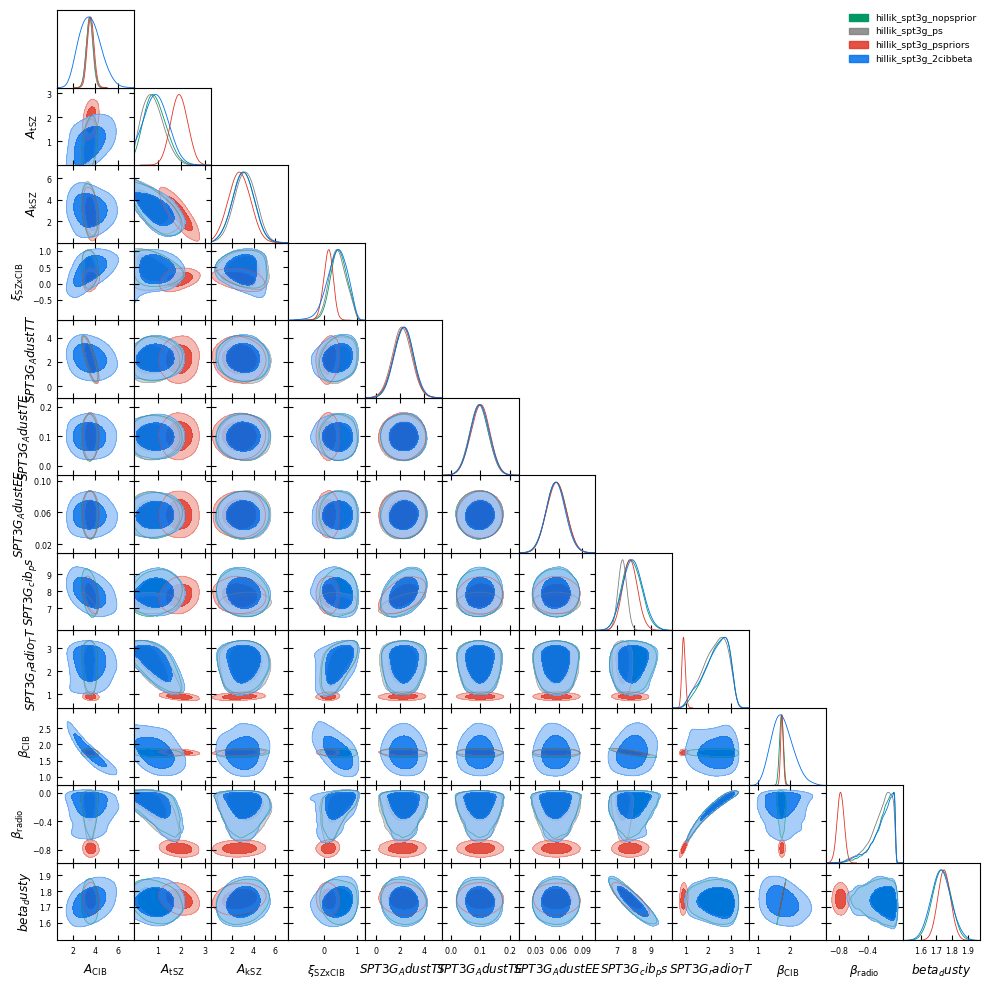

In [8]:
listpar = ['Acib','Atsz','Aksz','xi','SPT3G_AdustTT','SPT3G_AdustTE','SPT3G_AdustEE',
           'SPT3G_cib_ps','SPT3G_radio_TT','beta_cib','beta_radio','beta_dusty']
labels = [MCtools.parname.get(p,p).replace('$','') for p in listpar]
samples = [MCSamples(samples=[chain[p] for p in listpar if p in chain], 
                     names=[p for p in listpar if p in chain], 
                     labels=[MCtools.TexName(p) for p in listpar if p in chain], 
                     weights=chain['weight'],
                     ranges={'Atsz':(0,10),'Aksz':(0,10),'Acib':(0,15)}) for chain in chains]
g = plots.getSinglePlotter(width_inch=10, ratio=1)
g.triangle_plot(samples, listpar, filled=True, legend_labels=runnames, legend_loc='upper right')

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


<Figure size 1000x1000 with 0 Axes>

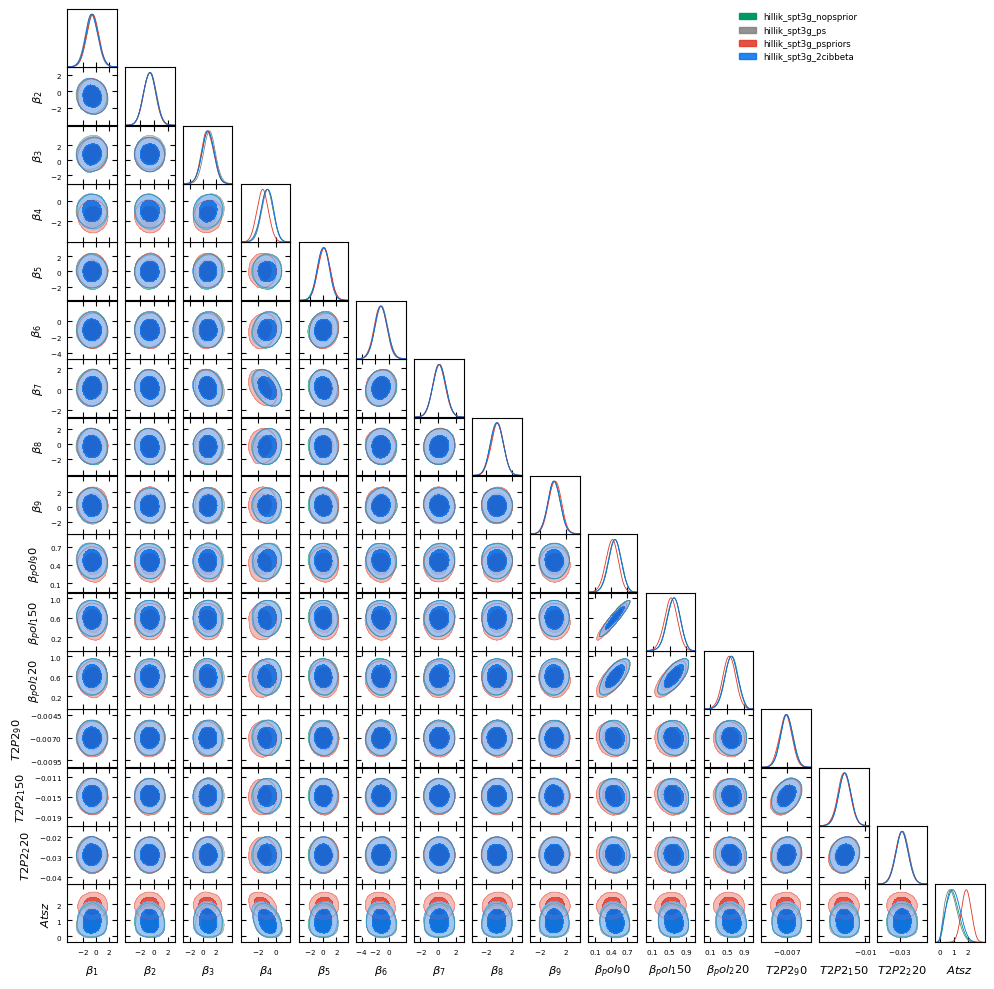

In [10]:
listpar = [p for p in chains[0].keys() if 'T2P2' in p or 'SPT3G_beta' in p]+['Atsz']
labels = [p.replace('SPT3G_','').replace('beta','\\beta') for p in listpar]
samples = [MCSamples( samples=[chain[p] for p in listpar], names=listpar, labels=labels, weights=chain['weight'], ranges={}) for chain in chains]
g = plots.getSinglePlotter(width_inch=10, ratio=1)
g.triangle_plot(samples, listpar, filled=True, legend_labels=runnames, legend_loc='upper right')